# Predicting heart failure with admission notes and large language models

Clinical notes are an important part of electronic health records (EHR), documenting a patient's journey in the hospital. Admission notes refer to the text written at the time of admission, and include initial details such as chief complaint, symptoms, and social/family background. These admission notes can be leveraged to predict patient outcomes during the visit such as mortality, length of stay, and diagnoses.

In this notebook, we will build an end-to-end inference pipeline for clinical text classification using the LLaMA large language model. Specifically, we will focus on predicting the occurrence of heart failure from admission notes. Our goal is to understand not only how to get predictions, but also how to format the data, interpret model behavior, and evaluate improvements from finetuning.



### Setup

- Create a copy of this notebook in your Drive.

- In Runtime, select Change runtime type, then choose **T4 GPU** as the hardware accelerator and **2025.07** as the runtime version, else the code will not work.  

- We will employ the Llama-3.2-1B-Instruct model for predictions. To use it, first log into Hugging Face and accept the [community license agreement](https://huggingface.co/meta-llama/Llama-3.2-1B-Instruct). Attention, this may take a while to be processed.

- Set your Hugging Face token as the variable **HF_TOKEN** in the Secrets tab (left menu, key icon) or paste your token in the "your_token" in the required field. Make sure not to accidentaly share it.

- Set your Weights and Biases API key as the variable **WANDB_KEY** in the Secrets tab (left menu, key icon) or paste your token in the "your_key" in the required field. Make sure not to accidentaly share it.

In [1]:
import torch, os, re, json, pprint, wandb, zipfile, itertools
import torch.nn.functional as F
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm
from torch.utils.data import DataLoader
from peft import PeftModel
from transformers import AutoTokenizer, DataCollatorWithPadding, AutoModelForCausalLM
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve
)
from dotenv import load_dotenv

Check the environment to confirm the GPU is available.

In [2]:
# Check for CUDA, then MPS (Apple Silicon), then fallback to CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("CUDA GPU available:", torch.cuda.get_device_name(0))
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Apple Silicon MPS GPU available.")
else:
    device = torch.device("cpu")
    print("No GPU available, using CPU.")

Apple Silicon MPS GPU available.


Set your Hugging Face and WandB keys.

In [3]:
# Load API keys from local .env file
load_dotenv()
hf_token = os.getenv("HF_TOKEN")
wandb_key = os.getenv("WANDB_KEY")

os.environ["HF_TOKEN"] = hf_token
wandb.login(key=wandb_key)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /Users/samha/.netrc
wandb: Currently logged in as: samhaaker12 (samhaaker12-university-of-amsterdam) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## Data exploration

In [4]:
import gdown

# Create local data directory
os.makedirs("./data", exist_ok=True)

# Download files using gdown python API instead of Colab's !gdown
folder_url = "https://drive.google.com/drive/folders/13G3EuZMZyLDG1wja7oEMuQN43YPWNj_U"
gdown.download_folder(folder_url, output="./data")

Retrieving folder contents


Processing file 12EkM_RCg4czn5v549UQYQ3YGeYh04gbN lora-adapter.zip
Processing file 1X_OS3vvQHKlWhwwWjLe2SWJ0M3wDIugv test-data.zip


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=12EkM_RCg4czn5v549UQYQ3YGeYh04gbN
From (redirected): https://drive.google.com/uc?id=12EkM_RCg4czn5v549UQYQ3YGeYh04gbN&confirm=t&uuid=08fcf75a-4aa3-4c84-88d9-b6a32bb22826
To: /Users/samha/Desktop/medical_ai/part3/Heart-Failure-Prediction-Group17/data/lora-adapter.zip
100%|██████████| 75.2M/75.2M [00:03<00:00, 24.5MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1X_OS3vvQHKlWhwwWjLe2SWJ0M3wDIugv
From (redirected): https://drive.google.com/uc?id=1X_OS3vvQHKlWhwwWjLe2SWJ0M3wDIugv&confirm=t&uuid=d4604182-3d62-406c-8da2-8956838e9e0d
To: /Users/samha/Desktop/medical_ai/part3/Heart-Failure-Prediction-Group17/data/test-data.zip
100%|██████████| 9.47M/9.47M [00:00<00:00, 22.0MB/s]
Download completed


['./data/lora-adapter.zip', './data/test-data.zip']

In [4]:
# load data

test_zip = Path("data/test-data.zip")
test_dir = Path("data")

def unzip_data(zip, dir, pwd=False):
  file_name = str(zip).split("/")[-1]
  with zipfile.ZipFile(zip, "r") as zf:
    if pwd:
      while True:
        try:
          #password = input(f"Enter password for {file_name}: ")
          password = "mam11_2025_amsterdam"
          zf.extractall(dir, pwd=password.encode())
          break
        except RuntimeError as e:
          print("Wrong password, try again.")
    else: zf.extractall(dir)
  print(f"{file_name} ready at {dir}")

unzip_data(test_zip, test_dir, pwd=True)

test-data.zip ready at data


### 1. Questions about data exploration (Q1–Q4)

In [5]:
path = "data/hf_baseline_test_concat_full.json"

# Q1: inspect the first admission note (index 0) before tokenization
# load the json file and print the raw text of the first note (prompt["input"])
with open(path) as f:
    d = json.load(f)
    print(d[0]["input"])

CHIEF COMPLAINT: fever, hypoxia

PRESENT ILLNESS: This is a ___ gentleman with PMHx Down's syndrome,  Alzheimer's dementia, dysphagia, and ?recurrent aspiration  pneumonia who presents from his group home with fever and  hypoxia of 87% on RA. Nonverbal at baseline.

MEDICAL HISTORY: Past Medical History:   1.  Down syndrome. 2.  Alzheimer's dementia. 3.  Obsessive-compulsive disorder. 4.  Hypothyroidism. 5.  Oropharyngeal dysphagia. 6.  GERD. 7.  Hyperlipidemia. 8.  Recent fractured mandible. 9.  Recurrent aspiration

MEDICATION ON ADMISSION: The Preadmission Medication list may be inaccurate and requires  futher investigation. 1. Donepezil 10 mg PO QAM  2. Aspirin 81 mg PO DAILY  3. Atorvastatin 10 mg PO HS  4. Cyanocobalamin 1000 mcg PO DAILY  5. Docusate Sodium 100 mg PO HS  6. HydrOXYzine 25 mg PO HS  7. Levothyroxine Sodium 150 mcg PO DAILY  8. Omeprazole 40 mg PO BID  9. Psyllium 1 PKT PO BID  10. RISperidone 0.5 mg PO QAM  11. RISperidone 4 mg PO HS  12. Sertraline 100 mg PO BID

In [6]:
# set up model and tokenizer
model_name = "meta-llama/Llama-3.2-1B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

In [7]:
# Q1: inspect the first admission note after tokenization.
# decode token ids back to tokens with tokenizer.batch_decode()
token_ids = tokenizer(d[0]["input"])["input_ids"]

tokenized_text = tokenizer.convert_ids_to_tokens(token_ids)

print(tokenized_text)

['<|begin_of_text|>', 'CH', 'IE', 'F', 'ĠCOM', 'PL', 'A', 'INT', ':', 'Ġfever', ',', 'Ġhyp', 'ox', 'ia', 'ĊĊ', 'PRESENT', 'ĠI', 'LL', 'NESS', ':', 'ĠThis', 'Ġis', 'Ġa', 'Ġ___', 'Ġgentleman', 'Ġwith', 'ĠPM', 'H', 'x', 'ĠDown', "'s", 'Ġsyndrome', ',', 'Ġ', 'ĠAlzheimer', "'s", 'Ġdementia', ',', 'Ġdys', 'ph', 'ag', 'ia', ',', 'Ġand', 'Ġ?', 'rec', 'urrent', 'Ġaspiration', 'Ġ', 'Ġpneumonia', 'Ġwho', 'Ġpresents', 'Ġfrom', 'Ġhis', 'Ġgroup', 'Ġhome', 'Ġwith', 'Ġfever', 'Ġand', 'Ġ', 'Ġhyp', 'ox', 'ia', 'Ġof', 'Ġ', '87', '%', 'Ġon', 'ĠRA', '.', 'ĠNon', 'ver', 'bal', 'Ġat', 'Ġbaseline', '.ĊĊ', 'MED', 'ICAL', 'ĠHISTORY', ':', 'ĠPast', 'ĠMedical', 'ĠHistory', ':', 'ĠĠ', 'Ġ', '1', '.', 'Ġ', 'ĠDown', 'Ġsyndrome', '.', 'Ġ', '2', '.', 'Ġ', 'ĠAlzheimer', "'s", 'Ġdementia', '.', 'Ġ', '3', '.', 'Ġ', 'ĠObs', 'ess', 'ive', '-comp', 'ulsive', 'Ġdisorder', '.', 'Ġ', '4', '.', 'Ġ', 'ĠHyp', 'othy', 'roid', 'ism', '.', 'Ġ', '5', '.', 'Ġ', 'ĠO', 'roph', 'ary', 'nge', 'al', 'Ġdys', 'ph', 'ag', 'ia', '.', 'Ġ', '6', 

In [8]:
def format_chat_prompts(path, n_prompts="all"):
  with open(path, mode="r", encoding="utf-8") as data:
    all_prompts = json.load(data)
    prompts_to_process = all_prompts[:int(n_prompts)] if n_prompts != "all" else all_prompts
    chat_prompts = [prompt["instruction"] + prompt["input"] for prompt in prompts_to_process]
    labels = [prompt["output"] for prompt in prompts_to_process]

    results = []
    formatted_prompts = [
      [{"role": "user", "content": p}] for p in chat_prompts
  ]
    for prompt, label in zip(formatted_prompts, labels):
      results.append({"prompt": prompt, "label": label})

  return results

convs=format_chat_prompts(path)

prompts = [
    tokenizer.apply_chat_template(c["prompt"], tokenize=False, add_generation_prompt=True)
    for c in convs
]

tokenized = [tokenizer(p, truncation=True) for p in prompts]

In [9]:
collator = DataCollatorWithPadding(tokenizer=tokenizer, return_tensors="pt")

# Q2: compare left vs right padding on a batch of the first 4 samples
# how positional information, attention, and sequence generation interact with padding?

sample = tokenized[:4]

tokenizer.padding_side = "left"
batch_left = collator(sample)

tokenizer.padding_side = "right"
batch_right = collator(sample)

print(batch_left["input_ids"][2][:100])
print(batch_left["attention_mask"][2][:100])

print(batch_right["input_ids"][2][-100:])
print(batch_right["attention_mask"][2][-100:])

# recover the left padding for the Llamma model
tokenizer.padding_side = "left"

tensor([128009, 128009, 128009, 128009, 128009, 128009, 128009, 128009, 128009,
        128009, 128009, 128009, 128009, 128009, 128009, 128009, 128009, 128009,
        128009, 128009, 128009, 128009, 128009, 128009, 128009, 128009, 128000,
        128000, 128006,   9125, 128007,    271,  38766,   1303,  33025,   2696,
            25,   6790,    220,   2366,     18,    198,  15724,   2696,     25,
           220,   2371,   5020,    220,   2366,     21,    271, 128009, 128006,
           882, 128007,    271,   2675,    527,    459,   6335,    304,  14830,
         23842,     13,  31001,   3508,    279,   8893,   1047,   4851,   8060,
          2391,    420,   4034,   3196,    389,    872,  26360,   5296,  12399,
            13,   9442,   1193,    264,   1396,   1990,   2033,  40029,     25,
          4416,     15,   5163,    369,   2360,     11,   4416,     16,   5163,
           369])
tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 1, 1, 

In [10]:
# batch the whole data
# batches are held by the dataloader
dataloader = DataLoader(tokenized, collate_fn=collator, batch_size=12) # do not change batch size!

In [11]:
# inspect a batch (used for Q3 and Q4 below)
batch = next(iter(dataloader)) # check input_ids, attention_mask

for k, v in batch.items():
    print(k, type(v), v.shape)

input_ids <class 'torch.Tensor'> torch.Size([12, 1493])
attention_mask <class 'torch.Tensor'> torch.Size([12, 1493])


In [12]:
# Q3: inspect several batches and compare their tensor shapes
# identify which dimensions stay constant and which vary across batches, using the first two batches as examples
iterator = iter(dataloader)

batch1 = next(iterator)
print(batch1["input_ids"].shape)

batch2 = next(iterator)
print(batch2["input_ids"].shape)

batch3 = next(iterator)
print(batch3["input_ids"].shape)

batch4 = next(iterator)
print(batch4["input_ids"].shape)

batch5 = next(iterator)
print(batch5["input_ids"].shape)


# Q4: Examine the first batch and identify notes with different sequence lengths
# Use attention_mask to find each note's unpadded length within the batch
unpadded_length = batch1["attention_mask"].sum(dim=1)
print(unpadded_length)

torch.Size([12, 1493])
torch.Size([12, 2548])
torch.Size([12, 1406])
torch.Size([12, 2170])
torch.Size([12, 1981])
tensor([ 842,  801, 1030, 1056, 1493,  219, 1285,  411,  973,  678,  879,  366])


# Inference (Q5–Q9)

With the formatted data, we can get the binary heart failure predictions. Attention, the jsonls with the results are automatically uploaded to Weights and Biases (Files tab of each run). If you run this once, no need to run it again to evaluate the results; just upload the files on Colab and specify the path in the Evaluation section.

## Predicting with base model

Load the Llama 3.2 model for making the first predictions.

In [13]:
model_name = "meta-llama/Llama-3.2-1B-Instruct"

# load model
model = AutoModelForCausalLM.from_pretrained(model_name,
                                             device_map="auto",
                                             trust_remote_code=True)

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

In [14]:
device = model.device  # use gpu

args = {
    "do_sample": False, # false = greedy decoding
    #"do_sample": True, # true = stochastic decoding
    #"temperature": 0.9,
    # "top_p": 0.9,
    # "top_k": 50,
}

In [15]:
# Q5: inspect run_batch() below and trace how a batch of tokenized notes becomes model predictions
def run_batch(model, batch, gen_args, max_tokens=4):
    # run inference in a batch of prompts
    batch = {k: v.to(device) for k, v in batch.items()} # move data to gpu
    return model.generate(
        **batch,
        max_new_tokens=max_tokens,
        return_dict_in_generate=True,
        output_scores=True, # save logits
        **gen_args # custom gen params
    )

# Q7/Q8: extract_preds() may be useful
def extract_preds(out, batch, convs, tokenizer, global_idx, tok_0, tok_1):
    # extract probs associated to both possible labels
    results = []

    for seq_id, seq in enumerate(out.sequences):
        input_len = batch["input_ids"].shape[1] # seq length of batch
        gen_tokens = seq[input_len:] # get only newly gen tokens; same as seq[-max_tokens:]
        token_strs = [tokenizer.decode([t], skip_special_tokens=False) for t in gen_tokens] # decode new token changed for local run
        pred = "".join(token_strs).replace("<|eot_id|>", "").strip() # clean pred
        c = convs[global_idx] # prompt id

        preds_info = None
        if token_strs and token_strs[0] == "[[": # only consider valid format
            logits = out.scores[1][seq_id] # pred is the 2nd gen token (pos = 1)
            probs = F.softmax(logits, dim=-1)

            # fetch logits and probs of 0, 1
            l0, l1 = logits[tok_0].item(), logits[tok_1].item()
            p0, p1 = probs[tok_0].item(), probs[tok_1].item()

            preds_info = {"logit_0": l0, "logit_1": l1, "prob_0": p0, "prob_1": p1}

        results.append({
            "prompt": c["prompt"],
            "predict": pred,
            "label": c["label"],
            "preds": preds_info # if invalid format, = null
        })
        global_idx += 1

    return results, global_idx

def save_jsonl(results, path):
    # save preds in jsonl
    with open(path, "w", encoding="utf-8") as f:
        for r in results:
            f.write(json.dumps(r, ensure_ascii=False) + "\n")

def batch_infer(loader, convs, tokenizer, gen_args, n_batches=20, max_tokens=4,
                save_path="/content/preds.jsonl", run_name="test_run"):
    # run batched inference with wandb logging
    wandb.init(project="mam11-inference", name=run_name, reinit=True) # init wandb
    results = []
    global_idx = 0

    # token ids for 0 and 1
    tok_0 = tokenizer("0", add_special_tokens=False)["input_ids"][0]
    tok_1 = tokenizer("1", add_special_tokens=False)["input_ids"][0]

    for n_batch, batch in enumerate(tqdm(itertools.islice(loader, n_batches), total=n_batches, desc="Processing batches")):
        out = run_batch(model, batch, gen_args=gen_args, max_tokens=max_tokens) # run inference
        batch_results, global_idx = extract_preds(out, batch, convs, tokenizer, global_idx, tok_0, tok_1) # extract preds
        results.extend(batch_results)
        wandb.log({"n_batch": n_batch + 1})

    if save_path is not None:
        save_jsonl(results, save_path)
        wandb.save(save_path) # dump jsonl in wandb

    wandb.finish()
    return results

In [16]:
# Q6: run inference on the first batch with run_batch(), save the result as out, and inspect out.sequences and out.scores
out = run_batch(model, batch, args, max_tokens=4)
print("\n")
print(out.sequences.shape)
print("\n")
for seq in out.scores:
  print(seq.shape)



torch.Size([12, 1497])


torch.Size([12, 128256])
torch.Size([12, 128256])
torch.Size([12, 128256])
torch.Size([12, 128256])


In [17]:
#inspecting for q6
example = 0  #choose example id of batch <12
#with left padding full length 
inputLen = batch["input_ids"].shape[1]

print(f"Diff: {out.sequences.shape[1] - batch["input_ids"].shape[1]}")
#last pred 
genIds = out.sequences[example, inputLen:]
print("generated text:", tokenizer.decode(genIds))

for step, stepScores in enumerate(out.scores):
    #logit to prob
    prob = F.softmax(stepScores[example], dim=-1)
    tokId = genIds[step].item()
    print(f"step {step}: token={tokenizer.decode([tokId])} id={tokId}  "
          f"p={prob[tokId]:.4f}")

[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Diff: 4
generated text: [[1]]<|eot_id|>
step 0: token=[[ id=15873  p=0.9518
step 1: token=1 id=16  p=0.6992
step 2: token=]] id=5163  p=0.9873
step 3: token=<|eot_id|> id=128009  p=0.9929


In [18]:
# run inference for the first 20 batches with basemodel using batch_infer()

preds_base_llama1b = batch_infer(
   dataloader,
   convs,
   tokenizer,
   args,
   n_batches=20,
   max_tokens=4,
   save_path="preds_base_llama1b.jsonl",
   run_name="base_llama1b"
)
#Als het goed is klopt het bovenstaande al, dus gewoon uitcommenten.

wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Processing batches:   0%|          | 0/20 [00:00<?, ?it/s]

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.
wandb: ERROR The nbformat package was not found. It is required to save notebook history.


n_batch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
n_batch,20


## Predicting with finetuned model


Now let's generate the predictions with the finetuned model by loading the LoRA adapter and running inference.

In [20]:
lora_zip = Path("data/lora-adapter.zip")
lora_dir = Path("data/lora-adapter")
unzip_data(lora_zip, lora_dir)

lora-adapter.zip ready at data/lora-adapter


In [21]:
adapter_path = "data/lora-adapter"
model = PeftModel.from_pretrained(model, adapter_path)
print(f"Loaded LoRA adapter from {adapter_path}")

Loaded LoRA adapter from data/lora-adapter


In [22]:
# run inference for the first 20 batches with finetuned model using batch_infer()

preds_ft_llama1b = batch_infer(
   dataloader,
   convs,
   tokenizer,
   args,
   n_batches=20,
   max_tokens=4,
   save_path="preds_ft_llama1b.jsonl",
   run_name="ft_llama1b"
)
# het codeblok hierboven heeft gerund, dus van de baseline, wat goed is. Echter, het probleem bij dit blok is nu dat ik geen memory heb.
#OutOfMemoryError: CUDA out of memory. Tried to allocate 956.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 511.81 MiB is free. Including non-PyTorch memory, this process has 14.06 GiB memory in use. Of the allocated memory 11.98 GiB is allocated by PyTorch, and 1.96 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

Processing batches:   0%|          | 0/20 [00:00<?, ?it/s]

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.
wandb: ERROR The nbformat package was not found. It is required to save notebook history.


n_batch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
n_batch,20


# Evaluation (Q9)

In [23]:
# Q9: compare the prediction for the first instance in the first batch between the base and fine-tuned models
# load the preds_base_llama1b.jsonl file and print the first base model prediction (index 0)
# load the preds_ft_llama1b.jsonl file and print the first finetuned model prediction (index 0)
# YOUR CODE HERE
b_path = "preds_base_llama1b.jsonl"
f_path = "preds_ft_llama1b.jsonl"

with open(b_path, "r", encoding="utf-8") as f:
    line = json.loads(f.readline())
    print(line["predict"])
    print(f"actueal {line["label"]}")
    twoProbs = F.softmax(torch.tensor([line["preds"]["logit_0"], line["preds"]["logit_1"]]), dim=-1)
    print(f"confidence {twoProbs.max():.4f}")

with open(f_path, "r", encoding="utf-8") as f:
    line = json.loads(f.readline())
    print(line["predict"])
    print(f"actueal {line["label"]}")
    twoProbs = F.softmax(torch.tensor([line["preds"]["logit_0"], line["preds"]["logit_1"]]), dim=-1)
    print(f"confidence {twoProbs.max():.4f}")

[[1]]
actueal [[0]]
confidence 0.7311
[[0]]
actueal [[0]]
confidence 0.9466


# Evaluation (Q10–Q12)

Calculate the performance metrics.

In [27]:
pat = re.compile(r"\[\[\s*([01])\s*\]\]")
def to01(x):
    """
    task, convert raw labels to int 0 or 1.

    expected input, any value that may contain a label.
    expected output, int 0 or 1 or none.
    """
    if x is None: return None
    s = str(x).strip()
    m = pat.search(s)
    if m: return int(m.group(1))
    if s in {"0","1"}: return int(s)
    return None

def load_df(path):
    """
    task, load predictions jsonl to a dataframe.

    use, read lines, json.loads, build columns prompt, pred, label, p1.

    expected input, path to jsonl created by batch_infer.
    expected output, pandas dataframe with the four columns.
    """
    # TODO, read non empty lines
    rows = []
    with open(path, "r", encoding="utf-8") as f:
      for line in f:
        line = line.strip()
        if not line:
          continue
        # TODO, parse json and build dataframe
        row = json.loads(line)
        rows.append({
            "prompt": row["prompt"],
            "pred": to01(row["predict"]),
            # TODO, use to01 to normalize predict and label
            "label": to01(row["label"]),
            "p1": row["preds"]["prob_1"] if row["preds"] else None
        })
    return pd.DataFrame(rows)
    # TODO, pick prob_1 when preds exists, else None
df_base = load_df(b_path)
df_ft = load_df(f_path)
print(df_base.head())
print(df_ft.head())

# dataset summary
print("\n=== Dataset summary ===")
print(f"Total processed prompts: {len(df_base)}")
print(f"Missing labels: {df_base['label'].isna().sum()}")
print(f"Missing base preds: {df_base['pred'].isna().sum()}")
print(f"Missing finetuning preds: {df_ft['pred'].isna().sum()}")
print("\n=== Label distribution ===")
labelCounts = df_base["label"].value_counts().sort_index()
labelProps = df_base["label"].value_counts(normalize=True).sort_index()
print(f"no heart failure (0): {labelCounts[0]} ({labelProps[0]:.1%})")
print(f"heart failure (1): {labelCounts[1]} ({labelProps[1]:.1%})")

                                              prompt  pred  label        p1
0  [{'role': 'user', 'content': 'You are an exper...     1      0  0.699228
1  [{'role': 'user', 'content': 'You are an exper...     1      0  0.790698
2  [{'role': 'user', 'content': 'You are an exper...     1      1  0.860752
3  [{'role': 'user', 'content': 'You are an exper...     1      0  0.862750
4  [{'role': 'user', 'content': 'You are an exper...     1      0  0.876868
                                              prompt  pred  label        p1
0  [{'role': 'user', 'content': 'You are an exper...     0      0  0.053399
1  [{'role': 'user', 'content': 'You are an exper...     0      0  0.014063
2  [{'role': 'user', 'content': 'You are an exper...     1      1  0.966768
3  [{'role': 'user', 'content': 'You are an exper...     0      0  0.009708
4  [{'role': 'user', 'content': 'You are an exper...     0      0  0.020331

=== Dataset summary ===
Total processed prompts: 240
Missing labels: 0
Missing base pre

In [25]:

def error_label_dist(name, y_true, y_pred):
    """
    task, summarize wrong predictions by true label.

    use, pandas boolean masks and value_counts.

    expected input, two pandas series.
    expected output, dataframe with label, count, prop, and model columns.
    """
    # TODO, mask valid items and wrong items
    valid = y_true.notna() & y_pred.notna()
    wrong = valid & (y_true != y_pred)
    # TODO, compute counts and proportions per true label
    counts = y_true[wrong].value_counts().sort_index()
    props = counts/counts.sum()
    # TODO, return a dataframe with the required columns
    return pd.DataFrame({
        "label": counts.index,
        "count": counts.values,
        "prop": props.values,
        "model": name
    })

valid = (
    df_base["label"].notna()
    & df_base["pred"].notna()
    & df_ft["pred"].notna()
    )

base_errors = error_label_dist(
    "base",
    df_base["label"],
    df_base["pred"]
    )


ft_errors = error_label_dist(
    "ft",
    df_ft["label"],
    df_ft["pred"]
    )

error_dist = pd.concat(
    [base_errors, ft_errors],
    ignore_index=True
    )

# error label distribution
print("\n=== Error label distribution ===")
print("\n=== Model disagreements ===")
print(f"Disagreements total: {(valid & (df_base['pred'] != df_ft['pred'])).sum()}")
print(f"Base wrong, finetuned right: {(valid & (df_base['label'] != df_base['pred']) & (df_ft['label'] == df_ft['pred'])).sum()}")
print(f"Base right, finetuned wrong: {(valid & (df_base['label'] == df_base['pred']) & (df_ft['label'] != df_ft['pred'])).sum()}")
print(error_dist)


=== Error label distribution ===

=== Model disagreements ===
Disagreements total: 183
Base wrong, finetuned right: 168
Base right, finetuned wrong: 15
   label  count   prop model
0      0    177  1.000  base
1      0      9  0.375    ft
2      1     15  0.625    ft


In [26]:
# Q12: compute accuracy, precision, recall, F1 score, AUROC, and AUPRC for both the base and fine-tuned models
def compute_metrics(name, y_true, y_pred, y_prob):
    """
    task, compute core metrics for a binary task.

    use from scikit learn:
      accuracy_score,
      precision_recall_fscore_support with average "binary",
      roc_auc_score,
      average_precision_score.

    expected input, pandas series for y_true and y_pred, list or series for y_prob.
    expected output, dict with Acc, Prec, Rec, F1, AUROC, AUPRC.
    """
    # TODO, mask valid y_true and y_pred then cast to int numpy arrays
    valid_pred = y_true.notna() & y_pred.notna()

    y_true_pred = y_true[valid_pred].astype(int).to_numpy()
    y_pred_valid = y_pred[valid_pred].astype(int).to_numpy()

    # TODO, compute accuracy and precision recall f1
    acc = accuracy_score(y_true_pred, y_pred_valid)

    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true_pred,
        y_pred_valid,
        average="binary",
        zero_division=0
        )

    # TODO, if y_prob is provided and valid, compute roc auc and average precision
    valid_prob = valid_pred & y_prob.notna()

    if valid_prob.sum() > 0 and y_true[valid_prob].nunique() == 2:
      y_true_prob = y_true[valid_prob].astype(int).to_numpy()
      y_prob_valid = y_prob[valid_prob].astype(float).to_numpy()

      auroc = roc_auc_score(y_true_prob, y_prob_valid)
      auprc = average_precision_score(y_true_prob, y_prob_valid)

    else:
      auroc = None
      auprc = None


    # TODO, return a dict with requested fields and the model name
    return {
        "model": name,
        "Acc": acc,
        "Prec": prec,
        "Rec": rec,
        "F1": f1,
        "AUROC": auroc,
        "AUPRC": auprc
    }

# === Metrics table ===
#    Model   Acc  Prec   Rec    F1  AUROC  AUPRC

# YOUR CODE HERE
metrics_base = compute_metrics(
    "base",
    df_base["label"],
    df_base["pred"],
    df_base["p1"]
)
metrics_ft = compute_metrics(
    "ft",
    df_ft["label"],
    df_ft["pred"],
    df_ft["p1"]
)

metrics_table = pd.DataFrame([metrics_base, metrics_ft])
metrics_table = metrics_table[["model", "Acc", "Prec", "Rec", "F1", "AUROC", "AUPRC"]]
print(metrics_table)

  model     Acc      Prec       Rec        F1     AUROC     AUPRC
0  base  0.2625  0.262500  1.000000  0.415842  0.589902  0.307460
1    ft  0.9000  0.842105  0.761905  0.800000  0.936329  0.871601


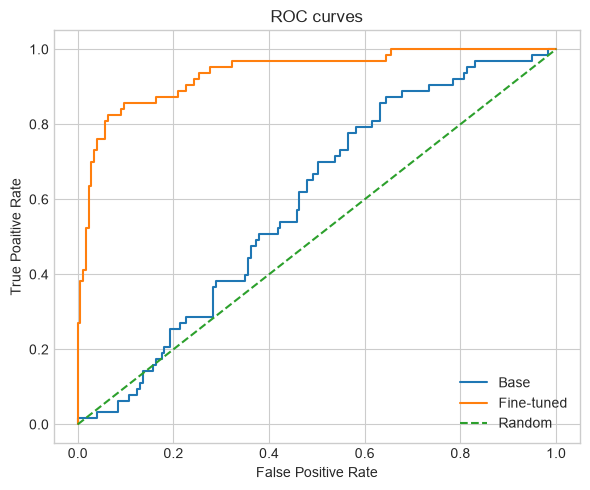

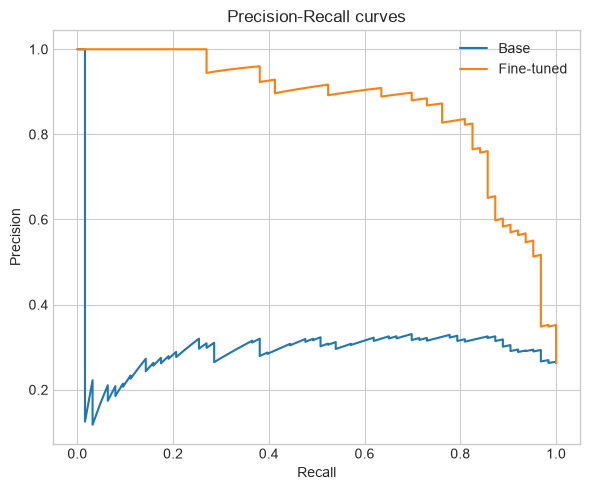

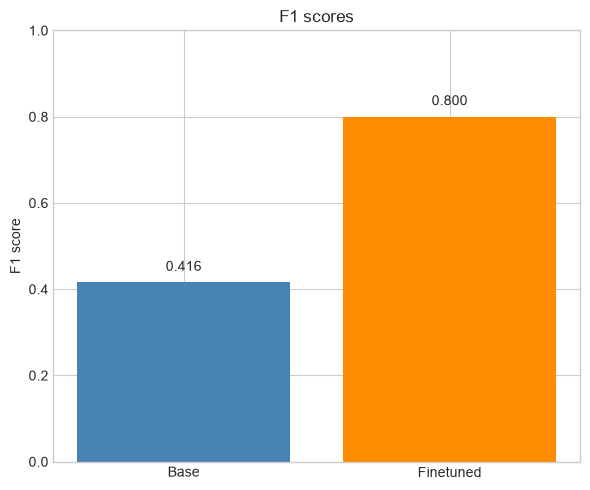

In [30]:
plt.style.use("seaborn-v0_8-whitegrid")  # prettier plots

def plot_all(labels, p1_base, p1_ft, base_metrics, ft_metrics):
    """
    task, plot ROC, PR, and F1 comparison for two models.

    use from scikit learn, roc_curve and precision_recall_curve.
    use matplotlib to draw two line plots plus a bar chart.

    expected input, true labels and two score lists, plus metric dicts.
    expected output, three figures on screen.
    """
    # TODO, build masks for valid scores
    valid_base = labels.notna() & p1_base.notna()
    valid_ft = labels.notna() & p1_ft.notna()

    # TODO, compute curves for base and finetuned
    fpr_base, tpr_base, _ = roc_curve(labels[valid_base], p1_base[valid_base])
    fpr_ft, tpr_ft, _ = roc_curve(labels[valid_ft], p1_ft[valid_ft])
    pr_base, rec_base, _ = precision_recall_curve(labels[valid_base], p1_base[valid_base])
    pr_ft, rec_ft, _ = precision_recall_curve(labels[valid_ft], p1_ft[valid_ft])

    # TODO, draw ROC with random reference line
    plt.figure(figsize=(6,5))
    plt.plot(fpr_base, tpr_base, label="Base")
    plt.plot(fpr_ft, tpr_ft, label="Fine-tuned")
    # diagonal line - performance of a random classifier
    plt.plot([0,1], [0,1], linestyle="--", label="Random")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Poaitive Rate")
    plt.title("ROC curves")
    plt.legend()
    plt.tight_layout()
    plt.show()
    # TODO, draw PR curves
    plt.figure(figsize=(6,5))
    plt.plot(rec_base, pr_base, label="Base")
    plt.plot(rec_ft, pr_ft, label="Fine-tuned")

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall curves")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # TODO, draw F1 bar chart and annotate values
    model_names = ["Base", "Finetuned"]
    f1_scores = [base_metrics["F1"], ft_metrics["F1"]]

    plt.figure(figsize=(6,5))
    bars = plt.bar(
        model_names,
        f1_scores,
        color= ["steelblue", "darkorange"]
        )

    plt.ylim(0,1)
    plt.ylabel("F1 score")
    plt.title("F1 scores")

    for bar, score in zip(bars, f1_scores):
      plt.text(
          bar.get_x() + bar.get_width() / 2,
          score + 0.02,
          f"{score:.3f}",
          ha="center",
          va="bottom"
          )

    # TODO, tidy and show
    plt.tight_layout()
    plt.show()
plot_all(df_base["label"], df_base["p1"], df_ft["p1"], metrics_base, metrics_ft)

# Decoding (Q13–Q15)

For answering these questions, you've already been introduced to the functions you should use, in the Inference part.

In [31]:
# Q13: investigate how decoding temperature affects heart failure prediction performance for both the base and fine-tuned models
# evaluate each model with at least 3 temperature values
# for each model + temperature combination, compute accuracy, AUROC, and AUPRC
# YOUR CODE HERE
temp01 = {"do_sample": True, "temperature": 0.1}
temp05 = {"do_sample": True, "temperature": 0.5}
temp09 = {"do_sample": True, "temperature": 0.9}

# disable switches the lora layers off (found this to be easiest fix else memory to high with many models etc)
with model.disable_adapter():
    preds_base_t01 = batch_infer(
       dataloader,
       convs,
       tokenizer,
       temp01,
       n_batches=20,
       max_tokens=4,
       save_path="preds_base_t01.jsonl",
       run_name="base_t01"
    )

    preds_base_t05 = batch_infer(
       dataloader,
       convs,
       tokenizer,
       temp05,
       n_batches=20,
       max_tokens=4,
       save_path="preds_base_t05.jsonl",
       run_name="base_t05"
    )

    preds_base_t09 = batch_infer(
       dataloader,
       convs,
       tokenizer,
       temp09,
       n_batches=20,
       max_tokens=4,
       save_path="preds_base_t09.jsonl",
       run_name="base_t09"
    )

# the ft model now we need the lora layers so outside the with
preds_ft_t01 = batch_infer(
   dataloader,
   convs,
   tokenizer,
   temp01,
   n_batches=20,
   max_tokens=4,
   save_path="preds_ft_t01.jsonl",
   run_name="ft_t01"
)

preds_ft_t05 = batch_infer(
   dataloader,
   convs,
   tokenizer,
   temp05,
   n_batches=20,
   max_tokens=4,
   save_path="preds_ft_t05.jsonl",
   run_name="ft_t05"
)

preds_ft_t09 = batch_infer(
   dataloader,
   convs,
   tokenizer,
   temp09,
   n_batches=20,
   max_tokens=4,
   save_path="preds_ft_t09.jsonl",
   run_name="ft_t09"
)

Processing batches:   0%|          | 0/20 [00:00<?, ?it/s]

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.
wandb: ERROR The nbformat package was not found. It is required to save notebook history.


n_batch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
n_batch,20


Processing batches:   0%|          | 0/20 [00:00<?, ?it/s]

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.
wandb: ERROR The nbformat package was not found. It is required to save notebook history.


...

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.
wandb: ERROR The nbformat package was not found. It is required to save notebook history.


n_batch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
n_batch,20


Processing batches:   0%|          | 0/20 [00:00<?, ?it/s]

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.
wandb: ERROR The nbformat package was not found. It is required to save notebook history.


n_batch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
n_batch,20


In [32]:
#Lets make metrics again
dfBaseT01 = load_df("preds_base_t01.jsonl")
dfBaseT05 = load_df("preds_base_t05.jsonl")
dfBaseT09 = load_df("preds_base_t09.jsonl")
dfFtT01 = load_df("preds_ft_t01.jsonl")
dfFtT05 = load_df("preds_ft_t05.jsonl")
dfFtT09 = load_df("preds_ft_t09.jsonl")

metricsBaseT01 = compute_metrics("base t=0.1", dfBaseT01["label"], dfBaseT01["pred"], dfBaseT01["p1"])
metricsBaseT05 = compute_metrics("base t=0.5", dfBaseT05["label"], dfBaseT05["pred"], dfBaseT05["p1"])
metricsBaseT09 = compute_metrics("base t=0.9", dfBaseT09["label"], dfBaseT09["pred"], dfBaseT09["p1"])
metricsFtT01 = compute_metrics("ft t=0.1", dfFtT01["label"], dfFtT01["pred"], dfFtT01["p1"])
metricsFtT05 = compute_metrics("ft t=0.5", dfFtT05["label"], dfFtT05["pred"], dfFtT05["p1"])
metricsFtT09 = compute_metrics("ft t=0.9", dfFtT09["label"], dfFtT09["pred"], dfFtT09["p1"])

tempTable = pd.DataFrame([metricsBaseT01, metricsBaseT05, metricsBaseT09,metricsFtT01, metricsFtT05, metricsFtT09])
tempTable = tempTable[["model", "Acc", "AUROC", "AUPRC"]]
print(tempTable)

# invalid format count per run is interesting as might go up (temp maybe not predicting [[]])
print("\n Missing preds!!!!")
print(f"base t=0.1: {dfBaseT01['pred'].isna().sum()}")
print(f"base t=0.5: {dfBaseT05['pred'].isna().sum()}")
print(f"base t=0.9: {dfBaseT09['pred'].isna().sum()}")
print(f"ft t=0.1: {dfFtT01['pred'].isna().sum()}")
print(f"ft t=0.5: {dfFtT05['pred'].isna().sum()}")
print(f"ft t=0.9: {dfFtT09['pred'].isna().sum()}")

        model       Acc     AUROC     AUPRC
0  base t=0.1  0.262500  0.500000  0.262500
1  base t=0.5  0.276151  0.551723  0.285756
2  base t=0.9  0.357447  0.599915  0.306824
3    ft t=0.1  0.904167  0.864541  0.724577
4    ft t=0.5  0.904167  0.902924  0.799467
5    ft t=0.9  0.862500  0.908080  0.810907

 Missing preds!!!!
base t=0.1: 0
base t=0.5: 1
base t=0.9: 5
ft t=0.1: 0
ft t=0.5: 0
ft t=0.9: 0


In [35]:
# Q14: run the fine-tuned model on the first batch using top-k sampling (do_sample=True, top_k=50)
# then repeat using top-p sampling (do_sample=True, top_p=0.9)
# # use run_batch() for both
# YOUR CODE HERE

topK = {"do_sample": True, "top_k": 50}
topP = {"do_sample": True, "top_p": 0.9}

# adapter is on, same as before with batch
outTopK = run_batch(model, batch, topK, max_tokens=4)
outTopP = run_batch(model, batch, topP, max_tokens=4)

# print the answers to check for report
#Added skip special as than we dont have end tokens if present
inputLen = batch["input_ids"].shape[1]
for example in range(len(batch["input_ids"])):
    textTopK = tokenizer.decode(outTopK.sequences[example, inputLen:], skip_special_tokens=True)
    textTopP = tokenizer.decode(outTopP.sequences[example, inputLen:], skip_special_tokens=True)
    print(f"{example}: label {convs[example]['label']}  top-k {textTopK}  top-p {textTopP}")

0: label [[0]]  top-k [[0]]  top-p [[0]]
1: label [[0]]  top-k [[0]]  top-p [[0]]
2: label [[1]]  top-k [[1]]  top-p [[1]]
3: label [[0]]  top-k [[0]]  top-p [[0]]
4: label [[0]]  top-k [[0]]  top-p [[0]]
5: label [[0]]  top-k [[0]]  top-p [[0]]
6: label [[0]]  top-k [[0]]  top-p [[0]]
7: label [[0]]  top-k [[0]]  top-p [[0]]
8: label [[0]]  top-k [[0]]  top-p [[0]]
9: label [[0]]  top-k [[0]]  top-p [[0]]
10: label [[1]]  top-k [[0]]  top-p [[0]]
11: label [[1]]  top-k [[0]]  top-p [[0]]


In [ ]:
# Q15: compare predictions from the fine-tuned model using the four decoding strategies
# evaluate each strategy on the same test examples and report metrics
# YOUR CODE HERE

# Evaluation (Q16–Q18)

In [ ]:
# Q16: implement a confidence-based classifier
# accept predictions where max(p0, p1) > 0.9, reject the rest as uncertain
# YOUR CODE HERE

In [ ]:
# Q17: plot calibration curves for the base and fine-tuned models using
# sklearn.calibration.calibration_curve with n_bins=10, including the ideal calibration line
# YOUR CODE HERE

In [ ]:
# Q17 (continued): compute the Brier score for both models and relate it to the calibration curves
from sklearn.metrics import brier_score_loss

# YOUR CODE HERE